In [31]:
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [5]:
data_link = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
data = pd.read_csv(data_link)

# checking the first five rows
print(data.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [6]:
#checking the structure of the data
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None


In [7]:
# changing the data types for the categorical variables
categorical_variables = ['sex','smoker','day','time']
for col in categorical_variables:
    data[col] = data[col].astype('category')

# checking on changes
print(data.dtypes)

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object


In [9]:
# summary statistics for continous columns
summary = data[['total_bill', 'tip', 'size']].describe()
print(summary)

       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


In [20]:
# Grouped Summary statistics to identify trends by category
day_impact = data.groupby('day',observed=False)['tip'].agg(['mean', 'median', 'std', 'count'])
print(day_impact)

          mean  median       std  count
day                                    
Fri   2.734737   3.000  1.019577     19
Sat   2.993103   2.750  1.631014     87
Sun   3.255132   3.150  1.234880     76
Thur  2.771452   2.305  1.240223     62


In [10]:
# Strategic Insight: Check the 'Tip Percentage' to see the relative impact
data['tip_pct'] = (data['tip'] / data['total_bill']) * 100
print(data['tip_pct'].describe())

count    244.000000
mean      16.080258
std        6.107220
min        3.563814
25%       12.912736
50%       15.476977
75%       19.147549
max       71.034483
Name: tip_pct, dtype: float64


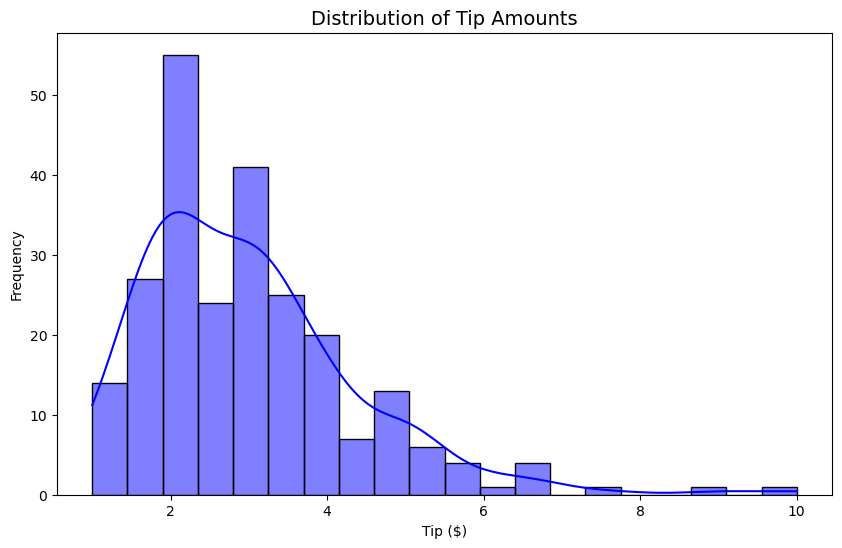

In [12]:
#Histogram to show distribution of the Tip
plt.figure(figsize=(10, 6))
sns.histplot(data['tip'], kde=True, color='blue', bins=20)
plt.title('Distribution of Tip Amounts', fontsize=14)
plt.xlabel('Tip ($)')
plt.ylabel('Frequency')
plt.show()

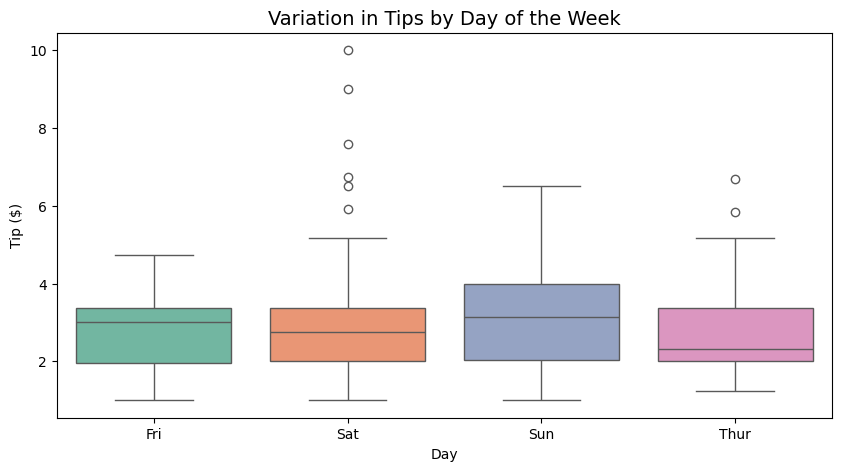

In [16]:
# checking for outliers in the tips data using box plot
plt.figure(figsize=(10, 5))
sns.boxplot(x='day', y='tip', data=data, palette='Set2',hue='day',legend=False)
plt.title('Variation in Tips by Day of the Week', fontsize=14)
plt.xlabel('Day')
plt.ylabel('Tip ($)')
plt.show()

In [18]:
# Grouped Summary Statistics: Useful for identifying trends by category
day_impact = data.groupby('day',observed=False)['tip'].agg(['mean', 'median', 'std', 'count'])
print(day_impact)

          mean  median       std  count
day                                    
Fri   2.734737   3.000  1.019577     19
Sat   2.993103   2.750  1.631014     87
Sun   3.255132   3.150  1.234880     76
Thur  2.771452   2.305  1.240223     62


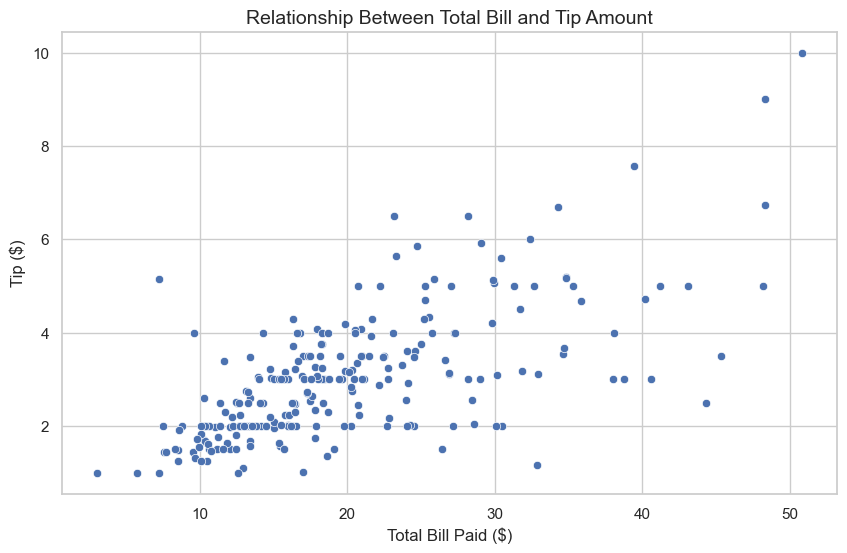

In [25]:
# Plotting scatter plot to show the relationship between total bill and tip
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='total_bill', y='tip')
plt.title('Relationship Between Total Bill and Tip Amount', fontsize=14)
plt.xlabel('Total Bill Paid ($)')
plt.ylabel('Tip ($)')
plt.show()

In [26]:
# Regression model using simple linear regression 
# Data preparation: Independent varibles will be total bill and size while the Dependent varible is tip
x = data[['total_bill','size']]
y = data['tip']

In [27]:
#splitting the data into Training anf Testing data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [29]:
# The model
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
# Predictions and Performance
predictions = model.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

In [34]:
print(f"\n--- Model Performance ---")
print(f"RMSE: ${rmse:.2f}")
print(f"R² Score: {r2:.4f}")


--- Model Performance ---
RMSE: $0.81
R² Score: 0.4811


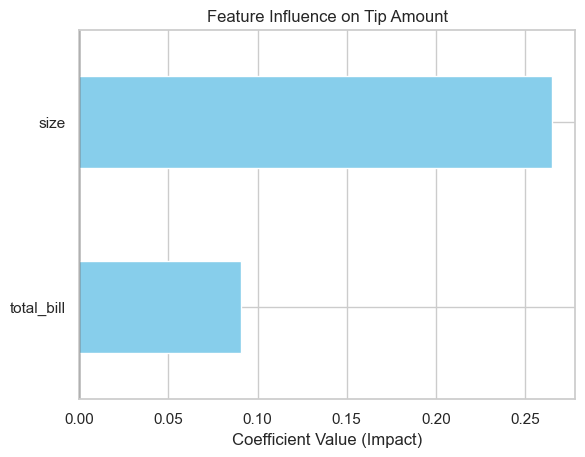

In [36]:
# Visualization: Influence of Variables
coefficients = pd.DataFrame(model.coef_, x.columns, columns=['Coefficient'])
coefficients.plot(kind='barh', color='skyblue', legend=False)
plt.title('Feature Influence on Tip Amount')
plt.xlabel('Coefficient Value (Impact)')
plt.axvline(0, color='black', lw=1)
plt.show()